# Dataset EDA - DDR2019 Processed Dataset

This notebook performs exploratory data analysis (EDA) on the processed DDR2019 dataset, with a focus on class distribution and imbalance analysis.

## Dataset Information
- **Dataset**: DDR2019 (Diabetic Retinopathy Detection)
- **Location**: `data/processed/ddr2019/`
- **Format**: CSV with columns `filename` and `label`
- **Classes**: 5 classes (0-4) representing different DR severity levels

In [1]:
# Set working directory to project root (must run first)
import os
from pathlib import Path

_path = Path.cwd()
while _path != _path.parent and not (_path / "pyproject.toml").exists():
    _path = _path.parent
PROJECT_ROOT = _path if (_path / "pyproject.toml").exists() else Path.cwd()
os.chdir(PROJECT_ROOT)
print(f"Working directory: {PROJECT_ROOT}")

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set style for better-looking plots
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')
    except OSError:
        plt.style.use('ggplot')
sns.set_palette("husl")

# Configuration (paths relative to project root)
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "ddr2019"
LABELS_CSV = DATA_DIR / "labels.csv"

print("Libraries imported successfully!")
print(f"Labels CSV path: {LABELS_CSV}")
print(f"CSV exists: {LABELS_CSV.exists()}")

Working directory: /Users/anaya/Develop/Robomous/sam-ai
Libraries imported successfully!
Labels CSV path: /Users/anaya/Develop/Robomous/sam-ai/data/processed/ddr2019/labels.csv
CSV exists: True


In [2]:
# Load the dataset
df = pd.read_csv(LABELS_CSV)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFirst few rows:")
print(df.head(10))
print(f"\nData types:")
print(df.dtypes)
print(f"\nBasic info:")
print(df.info())

Dataset shape: (12522, 2)

Column names: ['filename', 'label']

First few rows:
                filename  label
0  20170413102628830.jpg      0
1  20170413111955404.jpg      0
2  20170413112015395.jpg      0
3  20170413112017305.jpg      0
4  20170413112528859.jpg      0
5  20170413112758639.jpg      0
6  20170413112758698.jpg      0
7  20170413113351595.jpg      0
8  20170413113710974.jpg      0
9  20170413114550593.jpg      0

Data types:
filename    object
label        int64
dtype: object

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12522 entries, 0 to 12521
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  12522 non-null  object
 1   label     12522 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 195.8+ KB
None


In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Check for duplicates
print(f"\nDuplicate filenames: {df['filename'].duplicated().sum()}")
if df['filename'].duplicated().sum() > 0:
    print("\nDuplicate entries:")
    print(df[df['filename'].duplicated(keep=False)])

Missing values:
filename    0
label       0
dtype: int64

Total missing values: 0

Duplicate filenames: 0


In [4]:
# Class distribution analysis
class_counts = df['label'].value_counts().sort_index()
class_percentages = (df['label'].value_counts(normalize=True) * 100).sort_index()

print("Class Distribution:")
print("=" * 50)
for label in sorted(df['label'].unique()):
    count = class_counts[label]
    percentage = class_percentages[label]
    print(f"Class {label}: {count:6d} samples ({percentage:5.2f}%)")

print("=" * 50)
print(f"Total samples: {len(df)}")
print(f"Number of classes: {df['label'].nunique()}")
print(f"Class range: {df['label'].min()} - {df['label'].max()}")

Class Distribution:
Class 0:   6266 samples (50.04%)
Class 1:    630 samples ( 5.03%)
Class 2:   4477 samples (35.75%)
Class 3:    236 samples ( 1.88%)
Class 4:    913 samples ( 7.29%)
Total samples: 12522
Number of classes: 5
Class range: 0 - 4


In [5]:
# Calculate imbalance metrics
max_class_count = class_counts.max()
min_class_count = class_counts.min()
imbalance_ratio = max_class_count / min_class_count

print("Class Imbalance Metrics:")
print("=" * 50)
print(f"Most frequent class: {class_counts.idxmax()} ({max_class_count} samples)")
print(f"Least frequent class: {class_counts.idxmin()} ({min_class_count} samples)")
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}:1")
print(f"Standard deviation: {class_counts.std():.2f}")
print(f"Coefficient of variation: {(class_counts.std() / class_counts.mean() * 100):.2f}%")

Class Imbalance Metrics:
Most frequent class: 0 (6266 samples)
Least frequent class: 3 (236 samples)
Imbalance ratio (max/min): 26.55:1
Standard deviation: 2703.35
Coefficient of variation: 107.94%


## Class Distribution Visualization

The following visualizations show the class imbalance in the dataset.

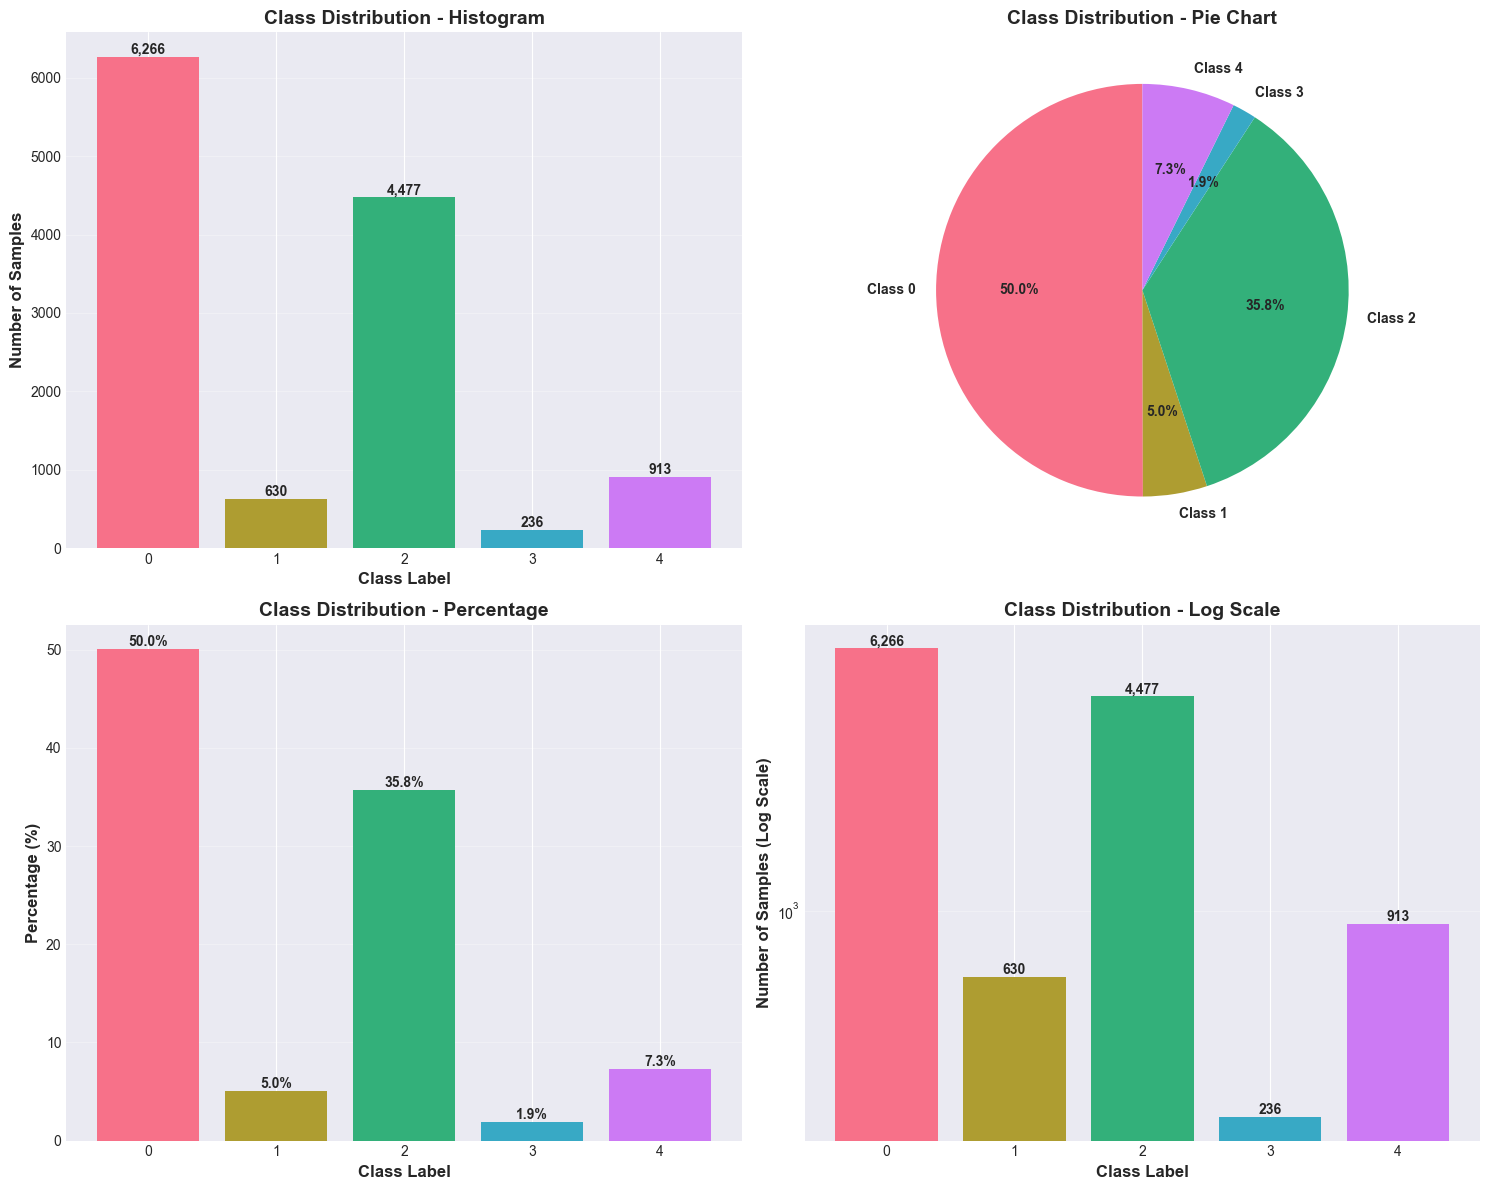

Class distribution visualizations created!


In [6]:
# Create histogram showing class imbalance
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Histogram - Class Distribution
ax1 = axes[0, 0]
bars = ax1.bar(class_counts.index.astype(str), class_counts.values, 
               color=sns.color_palette("husl", len(class_counts)))
ax1.set_xlabel('Class Label', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax1.set_title('Class Distribution - Histogram', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Percentage Pie Chart
ax2 = axes[0, 1]
colors = sns.color_palette("husl", len(class_counts))
wedges, texts, autotexts = ax2.pie(class_counts.values, 
                                    labels=[f'Class {i}' for i in class_counts.index],
                                    autopct='%1.1f%%',
                                    colors=colors,
                                    startangle=90,
                                    textprops={'fontsize': 10, 'fontweight': 'bold'})
ax2.set_title('Class Distribution - Pie Chart', fontsize=14, fontweight='bold')

# 3. Bar Chart with Percentages
ax3 = axes[1, 0]
bars = ax3.bar(class_counts.index.astype(str), class_percentages.values,
               color=sns.color_palette("husl", len(class_counts)))
ax3.set_xlabel('Class Label', fontsize=12, fontweight='bold')
ax3.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax3.set_title('Class Distribution - Percentage', fontsize=14, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 4. Log Scale Histogram (to better visualize imbalance)
ax4 = axes[1, 1]
bars = ax4.bar(class_counts.index.astype(str), class_counts.values,
               color=sns.color_palette("husl", len(class_counts)))
ax4.set_yscale('log')
ax4.set_xlabel('Class Label', fontsize=12, fontweight='bold')
ax4.set_ylabel('Number of Samples (Log Scale)', fontsize=12, fontweight='bold')
ax4.set_title('Class Distribution - Log Scale', fontsize=14, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("Class distribution visualizations created!")

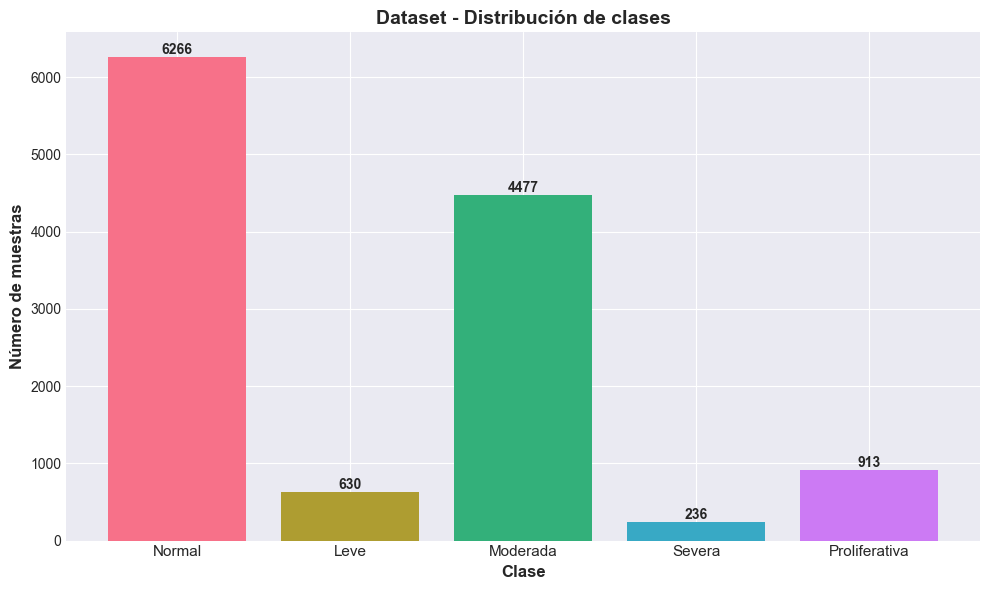

In [11]:
# Histogram: Dataset - Class Distribution (class labels in Spanish for this plot only)
LABEL_ES = {0: "Normal", 1: "Leve", 2: "Moderada", 3: "Severa", 4: "Proliferativa"}
labels_es = [LABEL_ES[int(k)] for k in class_counts.index]
x = np.arange(len(class_counts))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(x, class_counts.values, color=sns.color_palette("husl", len(class_counts)))
# Force Spanish labels: set ticks and labels explicitly (plt.xticks is often more reliable)
plt.xticks(ticks=x, labels=labels_es, fontsize=11)
ax.set_xlabel("Clase", fontsize=12, fontweight="bold")
ax.set_ylabel("Número de muestras", fontsize=12, fontweight="bold")
ax.set_title("Dataset - Distribución de clases", fontsize=14, fontweight="bold")

for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(int(count)),
            ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

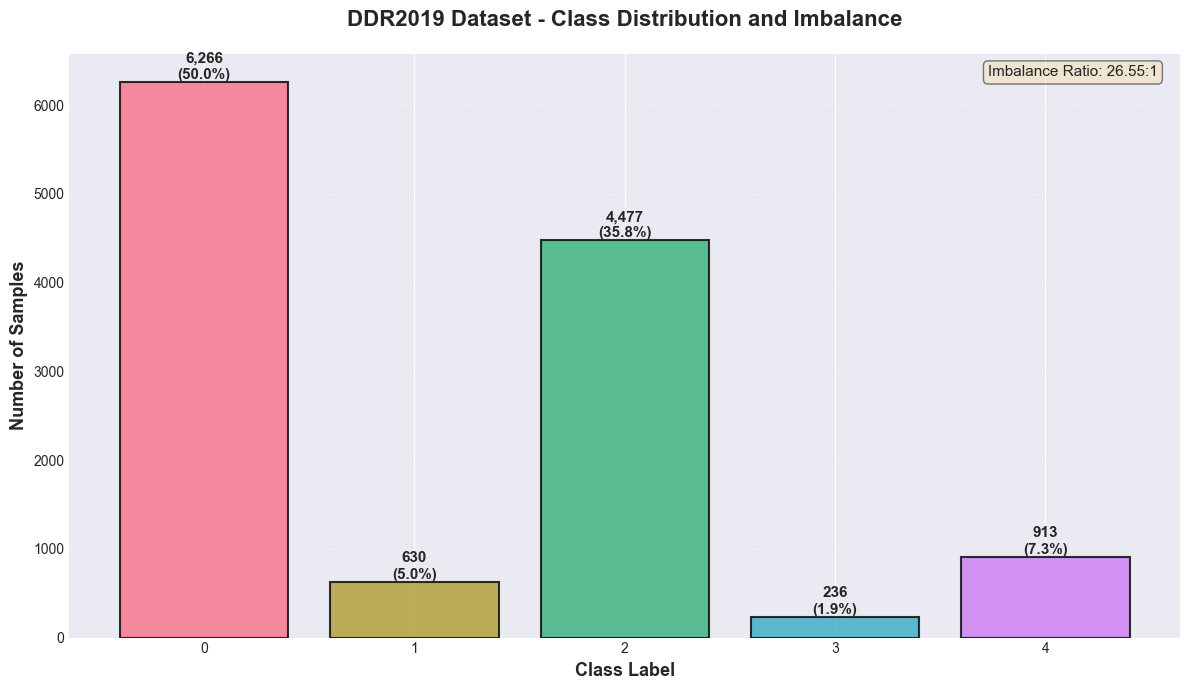

In [8]:
# Create a comprehensive single-figure visualization
fig, ax = plt.subplots(figsize=(12, 7))

# Create bar chart with counts
bars = ax.bar(class_counts.index.astype(str), class_counts.values,
              color=sns.color_palette("husl", len(class_counts)),
              edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on top of bars
for i, (bar, count, pct) in enumerate(zip(bars, class_counts.values, class_percentages.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count):,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize the plot
ax.set_xlabel('Class Label', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=13, fontweight='bold')
ax.set_title('DDR2019 Dataset - Class Distribution and Imbalance', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add imbalance ratio annotation
ax.text(0.98, 0.98, f'Imbalance Ratio: {imbalance_ratio:.2f}:1',
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## Summary Statistics

In [9]:
# Summary statistics table
summary_data = {
    'Class': [f'Class {i}' for i in sorted(df['label'].unique())],
    'Count': [class_counts[i] for i in sorted(df['label'].unique())],
    'Percentage': [f'{class_percentages[i]:.2f}%' for i in sorted(df['label'].unique())],
    'Ratio to Max': [f'{(class_counts[i] / max_class_count * 100):.1f}%' 
                     for i in sorted(df['label'].unique())]
}

summary_df = pd.DataFrame(summary_data)
print("Summary Statistics:")
print("=" * 60)
print(summary_df.to_string(index=False))
print("=" * 60)

Summary Statistics:
  Class  Count Percentage Ratio to Max
Class 0   6266     50.04%       100.0%
Class 1    630      5.03%        10.1%
Class 2   4477     35.75%        71.4%
Class 3    236      1.88%         3.8%
Class 4    913      7.29%        14.6%


## Key Findings

Based on the EDA:

1. **Total Samples**: The dataset contains processed images with their corresponding labels
2. **Class Imbalance**: Significant imbalance exists between classes
3. **Recommendations**: 
   - Consider using class weights during training
   - Use stratified sampling for train/val/test splits
   - Consider data augmentation for minority classes
   - Monitor per-class metrics during evaluation